In [1]:
from datetime import datetime as dt
import pandas as pd
import pandas_ta as ta
import numpy as np
import torch
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/stevenwinatamulia/Documents/skripsi-git//Documents/skripsi/ETHUSDT-4h-2020-2024.csv",delimiter=';')

In [3]:
#change timestamp into datetime
def timestamp_to_datetime(timestamp:list)->list:
    datetime = []
    for i in timestamp:
        datetime.append(dt.fromtimestamp(int(i)/1000))
    return datetime

df['open_time'] = timestamp_to_datetime(df['open_time'])
df['close_time'] = timestamp_to_datetime(df['close_time'])
df.index=df['open_time']

# feature engineering

In [4]:
# add SMA, RSI, and EMA

df['SMA_50'] = ta.sma(df['close'], 50)
df['RSI_14'] = ta.rsi(df['close'], 14)
df['RSI_21'] = ta.rsi(df['close'],21)
df['EMA_20'] = ta.ema(df['close'], 20)
df['EMA_34'] = ta.ema(df['close'], 34)
df = df.join(ta.bbands(df['close'], length=20, std=2))
df = df.join(ta.macd(df['close'], fast=12, slow=26, signal=9))
df_fix = df[[ 'open', 'high', 'low', 'close', 'volume','SMA_50', 'RSI_14', 'EMA_20','RSI_21','EMA_34']]

In [5]:
log_ret = pd.DataFrame()
log_ret['ret_close'] = np.log(df_fix.close) - np.log(df_fix.close.shift(1))
log_ret['sma50'] = df_fix['SMA_50']
log_ret['rsi14'] = df_fix['RSI_14']
log_ret['ema20'] = df_fix['EMA_20']
log_ret['rsi21'] = df_fix['RSI_21']
log_ret['ema34'] = df_fix['EMA_34']
log_ret = log_ret.join(ta.bbands(df['close'], length=30, std=2))
log_ret = log_ret.join(ta.bbands(df['close'], length=31, std=2))
log_ret = log_ret.join(ta.macd(df['close'], fast=12, slow=26, signal=9))
log_ret = log_ret.dropna()

In [6]:
# Pick all the columns that correlation >=0.1 with log-ret
correlation = []
for i in range(log_ret.corr(method='spearman').iloc[0].shape[0]):
    if np.abs(log_ret.corr(method='spearman').iloc[0][i]) >=0.1:
        correlation.append(i)

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_6958/3246183226.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.abs(log_ret.corr(method='spearman').iloc[0][i]) >=0.1:


In [7]:
col_name = log_ret.corr(method='spearman').iloc[0][correlation].index
col_name

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_6958/579759620.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_name = log_ret.corr(method='spearman').iloc[0][correlation].index


Index(['ret_close', 'rsi14', 'rsi21', 'BBP_30_2.0', 'BBP_31_2.0',
       'MACDh_12_26_9'],
      dtype='object')

# Data Fix (after cleaning and engineering)

In [8]:
XY_data = log_ret[col_name]

In [9]:
# Make the dataset for model train
XY_data['y'] = XY_data['ret_close'].shift(-1)
XY_data.columns = ['log_return','rsi14','rsi21','BB30','BB31','MACD','y']
XY_data.tail()

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_6958/1514433908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XY_data['y'] = XY_data['ret_close'].shift(-1)


,log_return,rsi14,rsi21,BB30,BB31,MACD,y
open_time,,,,,,,
2024-09-30 11:00:00,0.003062,46.236617,50.622382,0.405491,0.412349,-6.855071,-0.003316
2024-09-30 15:00:00,-0.003316,43.949577,49.088132,0.336007,0.340391,-7.393437,-0.012606
2024-09-30 19:00:00,-0.012606,36.598073,43.828611,0.080785,0.101049,-9.526301,-0.000216
2024-09-30 23:00:00,-0.000216,36.486268,43.744894,0.044491,0.101339,-10.459905,0.002694
2024-10-01 03:00:00,0.002694,38.995063,45.120723,0.074759,0.124045,-10.086594,NaN


# very fix data


In [10]:
# find relevant dates (some data will be sorted out)
XY_data.index = df.open_time.iloc[10387-10338:]

In [11]:
dataX = XY_data.iloc[:-1,:-1]
dataY = XY_data.iloc[5:-1,-1]

## Setting the Training and Testing Data

In [12]:
X_train = dataX[:7749].values.astype('float32')
y_train = dataY[:7749-6].values.astype('float32')

In [13]:
# combine 6 4h data into one matrix. (this will predict next 4h log-return) (train data)
X_train_modified = []

for i in range(len(X_train)-6):
    X_train_modified.append(X_train[i:i+6])

In [14]:
X_train_tensor = torch.from_numpy(np.array(X_train_modified))
y_train_tensor = torch.from_numpy(y_train).view(-1, 1) 

In [15]:
print(X_train_tensor.shape,y_train_tensor.shape)

torch.Size([7743, 6, 6]) torch.Size([7743, 1])


In [16]:
X_test = dataX[7749:].values.astype('float32')
y_test = dataY[7749:].values.astype('float32')

In [17]:
# combine 6 4h data into one matrix. (testing data) 

X_test_modified = []

for i in range(len(X_test)-5):
    X_test_modified.append(X_test[i:i+6])

In [18]:
X_test_tensor = torch.from_numpy(np.array(X_test_modified))
y_test_tensor = torch.from_numpy(y_test).view(-1, 1) 

In [19]:
print(X_test_tensor.shape,y_test_tensor.shape)

torch.Size([2583, 6, 6]) torch.Size([2583, 1])


In [20]:
X_train_check = dataX[:7749]#.values.astype('float32')
y_train_check = dataY[:7749-5]#.values.astype('float32')
X_test_check = dataX[7749:]#.values.astype('float32')
y_test_check = dataY[7749:]#.values.astype('float32')

# Setting Batch Size

In [21]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [22]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

# Setting Models

### <span style="color:red; font-size:20px; font-weight:bold;"> ⚠️ IMPORTANT: Adjust the Model According to the Assignment! </span>


In [23]:
batch_size = 16  # Adjusting Batch Size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [24]:
len(train_loader)

484

In [25]:
for i, batch in enumerate(test_loader):
    if i == len(test_loader) - 1:
        print(f"Last batch size: {len(batch[0])}")  # Assuming batch is (data, label)

Last batch size: 7


In [26]:
epochs = 50 # adjust epoch
hidden_size1 = 64 # adjust layer 1 size
hidden_size2 = 32 # adjust layer 2 size
hidden_size3 = 16 # adjust layer 3 size

In [27]:
class BidirectionalTestModel(nn.Module):
    def __init__(self, input_size=X_train_tensor.shape[-1], 
                 hidden_size_1=hidden_size1, hidden_size_2=hidden_size2, 
                 hidden_size_3=hidden_size3, output_size=1):
        super(BidirectionalTestModel, self).__init__()
        
        # First bidirectional GRU layer
        self.layer1 = nn.GRU(input_size=input_size, 
                             hidden_size=hidden_size_1,
                             batch_first=True,
                             bidirectional=True)  # Set bidirectional=True
        
        # Second bidirectional GRU layer
        self.layer2 = nn.LSTM(input_size=hidden_size_1 * 2,  # Double the input size
                             hidden_size=hidden_size_2,
                             batch_first=True,
                             bidirectional=True)  # Set bidirectional=True
        
        # Third bidirectional LSTM layer
        self.layer3 = nn.LSTM(input_size=hidden_size_2 * 2,  # Double the input size
                              hidden_size=hidden_size_3,
                              batch_first=True,
                              bidirectional=True)  # Set bidirectional=True
        
        # Final linear layer
        # Input size is doubled because of bidirectional RNN
        self.fc = nn.Linear(hidden_size_3 * 2, output_size)
        
    def forward(self, x):
        # Reshape input if it's not in the right format
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # Add sequence length dimension
            
        # First bidirectional GRU layer
        out, _ = self.layer1(x)
        
        # Second bidirectional GRU layer
        out, _ = self.layer2(out)
        
        # Third bidirectional LSTM layer
        out, _ = self.layer3(out)
        
        # Take the last output (forward and backward) and pass through final linear layer
        # For bidirectional RNNs, the last hidden state is concatenated as [forward, backward]
        out = self.fc(out[:, -1, :])
        
        return out

In [28]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = BidirectionalTestModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
# list(model_0.parameters())

### Setting Loss Function and Optimizer for NN training

In [29]:
# Creating Cauchy Loss Function
class CauchyLoss(nn.Module):
    def __init__(self, gamma=1.0):
        super(CauchyLoss, self).__init__()
        self.gamma = gamma

    def forward(self, y_pred, y_true):
        error = (y_true - y_pred) / self.gamma
        loss = torch.log(1 + error ** 2)
        return torch.mean(loss)

In [30]:
# Create the loss function
loss_fn =  CauchyLoss(gamma=0.00000001)

# Create the optimizer
optimizer = torch.optim.Adam(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.000001)

In [31]:
import time

## Model Training

In [32]:
torch.manual_seed(42)
# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

epoch_start_time = time.time()  # Start time for total training

for epoch in range(1,epochs+1):
    ### Training
    model_0.train()  # Put model in training mode
    train_loss = 0  # Track total training loss for the epoch
    iteration = 0
    # Iterate over batches in the training DataLoader
    for X_batch, y_batch in train_loader:
        # 1. Forward pass on train data
        y_pred = model_0(X_batch)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y_batch)

        # 3. Zero grad of the optimizer clears the gradients of all optimized tensors.
        optimizer.zero_grad()

        # 4. Loss backwards
        # This function computes the gradients of the loss with respect to the model parameters using backpropagation.
        loss.backward()

        # 5. Progress the optimizer
        
        optimizer.step()

        # Accumulate the training loss for the epoch
        train_loss += loss.item()

    # Calculate average training loss for the epoch
    train_loss /= len(train_loader)

    ### Testing
    model_0.eval()  # Put the model in evaluation mode
    y_preds = []
    test_loss = 0  # Track total testing loss for the epoch

    with torch.inference_mode():
        # Iterate over batches in the test DataLoader
        for X_batch, y_batch in test_loader:
            # 1. Forward pass on test data
            test_pred = model_0(X_batch)

            # 2. Calculate loss on test data
            test_loss += loss_fn(test_pred, y_batch).item()

        # Calculate average testing loss for the epoch
        test_loss /= len(test_loader)
    
    epoch_time = time.time() - epoch_start_time

    # Print out what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch:.6f} | Cauchy Train Loss: {train_loss:.6f} | Cauchy Test Loss: {test_loss}")

total_time = time.time() - epoch_start_time
print(f"\nTotal training time: {total_time:.2f} seconds, batch size is {batch_size} and epoch is {epochs}")

Epoch: 10.000000 | Cauchy Train Loss: 28.080234 | Cauchy Test Loss: 27.732053144478503
Epoch: 20.000000 | Cauchy Train Loss: 27.627422 | Cauchy Test Loss: 27.16142749786377
Epoch: 30.000000 | Cauchy Train Loss: 27.346940 | Cauchy Test Loss: 26.747144451847785
Epoch: 40.000000 | Cauchy Train Loss: 27.351998 | Cauchy Test Loss: 26.78621819578571
Epoch: 50.000000 | Cauchy Train Loss: 27.297274 | Cauchy Test Loss: 26.672331280178494

Total training time: 130.15 seconds, batch size is 16 and epoch is 50


In [33]:
print('underfit by: ', (test_loss / train_loss -1)*100,'%')

underfit by:  -2.2893945469168453 %


In [34]:
# Make training predictions
model_0.eval()
y_train_preds = []

with torch.inference_mode():
    for X_batch, _ in train_loader:
        y_pred = model_0(X_batch)
        y_train_preds.append(y_pred)

# Concatenate all predictions into a single tensor
y_train_preds = torch.cat(y_train_preds)

print("Predictions shape:", y_train_preds.shape)

Predictions shape: torch.Size([7743, 1])


In [35]:
# Make test predictions
model_0.eval()
y_preds = []

with torch.inference_mode():
    for X_batch, _ in test_loader:
        y_pred = model_0(X_batch)
        y_preds.append(y_pred)

# Concatenate all predictions into a single tensor
y_preds = torch.cat(y_preds)

print("Predictions shape:", y_preds.shape) 

Predictions shape: torch.Size([2583, 1])


In [36]:
# Convert prediction result to numpy for more analysis
prediction_train_np = y_train_preds.numpy()
prediction_np = y_preds.numpy()

In [37]:
prediction_np

array([[-0.00293184],
       [-0.00348514],
       [-0.0023774 ],
       ...,
       [ 0.00137964],
       [ 0.00052634],
       [-0.00052787]], shape=(2583, 1), dtype=float32)

In [38]:
# reshaping real data
y_train_np = y_train.reshape(prediction_train_np.shape[0],1)
y_test_np = y_test.reshape(prediction_np.shape[0],1)

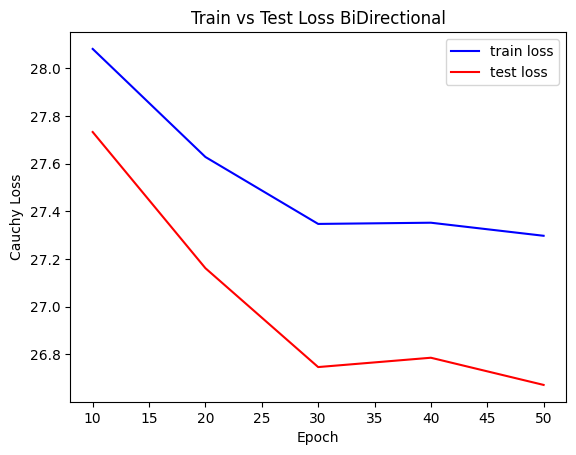

In [39]:
epoch_list = list(range(10,1+epochs,10))

plt.plot(epoch_list,train_loss_values,label='train loss',color='blue')
plt.plot(epoch_list,test_loss_values,label='test loss',color = 'red')
plt.xlabel('Epoch')
plt.ylabel('Cauchy Loss')
plt.title('Train vs Test Loss BiDirectional')

plt.legend()

plt.show()

# Combining return and data

## training data

In [40]:
close_train =  df.loc[X_train_check.iloc[6:].index].close.values

In [41]:
close_train_t1 = df.loc[X_train_check.iloc[5:-1].index].close.values
close_train_prediction = np.log(close_train_t1)+prediction_train_np.reshape(7743)
predicted_price_train = np.exp(close_train_prediction)

In [42]:
predicted_price_train.shape

(7743,)

## Testing Data

In [43]:
# filter for price testing
close_real = df.loc[(df.open_time>='2023-7-28 15:00')
& (df.open_time<'2024-10-01 3:00:00')].close.values # real data
print(close_real)
close_real.shape

[1865.77 1874.74 1873.4  ... 2627.97 2595.05 2594.49]


(2583,)

$ \log(\hat{P}_t) = \log(P_{t-1}) + \text{log\_ret}_t $

$ \hat{P}_t = \exp(\log(\hat{P}_t)) $

In [44]:
# first y_hat that we get is to predicting return
close_pred = np.log(df.loc[df.open_time>='2023-7-28 11:00'].close.values[:-2])
close_pred_logged = close_pred.reshape(close_pred.shape[0],1) + prediction_np

In [45]:
close_hat = np.exp(close_pred_logged)

In [46]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape

# return error

## train data return error

In [47]:
prediction_train_np = prediction_train_np.reshape(7743)

In [48]:
mse(prediction_train_np,y_train)

0.00043050467502325773

In [49]:
rmse(prediction_train_np,y_train)

0.020748605951666832

In [50]:
mae(prediction_train_np,y_train)

0.014383131638169289

In [51]:
mape(prediction_train_np,y_train)

32.40402603149414

## train data price error

In [52]:
mse(predicted_price_train,close_train)

1769.1179858220175

In [53]:
mse(close_train,predicted_price_train)

1769.1179858220175

In [54]:
rmse(predicted_price_train,close_train)

42.06088427294435

In [55]:
mae(predicted_price_train,close_train)

24.866415726090125

In [56]:
mape(predicted_price_train,close_train)

0.014381885719317701

## test data return error

In [57]:
mse(prediction_np,y_test)

0.0002033537020906806

In [58]:
rmse(prediction_np,y_test)

0.014260213822126389

In [59]:
mae(prediction_np,y_test)

0.010111824609339237

In [60]:
mape(prediction_np,y_test)

5.231891632080078

In [61]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test.reshape(2583,1),prediction_np)
print("R-squared:", r_squared)


R-squared: -0.4301682710647583


### Residuals

In [97]:
residuals_train  = y_train.reshape(-1) - prediction_train_np.reshape(-1)
residuals_train

array([-0.00552063,  0.00974988,  0.02779917, ...,  0.00818101,
        0.00301897,  0.00562797], shape=(7743,), dtype=float32)

In [98]:
residuals_test  = y_test.reshape(-1) - prediction_np.reshape(-1)
residuals_test

array([ 0.00772799,  0.00277011,  0.00237206, ..., -0.01398554,
       -0.00074216,  0.00322227], shape=(2583,), dtype=float32)

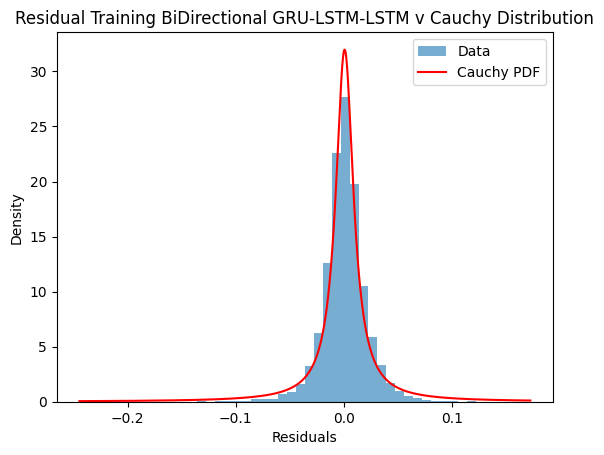

In [99]:
from scipy.stats import cauchy

data = residuals_train # log return atau residual Anda
loc = np.median(data)
scale = (np.quantile(data, 0.75) - np.quantile(data, 0.25)) / 2
x = np.linspace(min(data), max(data), 1000)

plt.title('Residual Training BiDirectional GRU-LSTM-LSTM v Cauchy Distribution')
plt.hist(data, bins=50, density=True, alpha=0.6, label='Data')
plt.plot(x, cauchy.pdf(x, loc=loc, scale=scale), 'r-', label='Cauchy PDF')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.show()

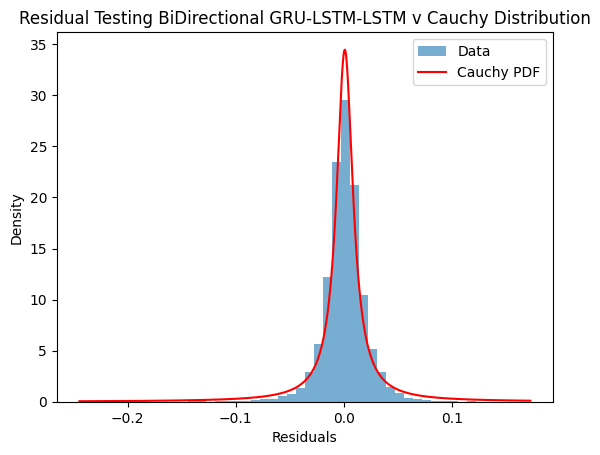

In [101]:
from scipy.stats import cauchy

data = residuals # log return atau residual Anda
loc = np.median(data)
scale = (np.quantile(data, 0.75) - np.quantile(data, 0.25)) / 2
x = np.linspace(min(data), max(data), 1000)

plt.title('Residual Testing BiDirectional GRU-LSTM-LSTM v Cauchy Distribution')
plt.hist(data, bins=50, density=True, alpha=0.6, label='Data')
plt.plot(x, cauchy.pdf(x, loc=loc, scale=scale), 'r-', label='Cauchy PDF')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.show()

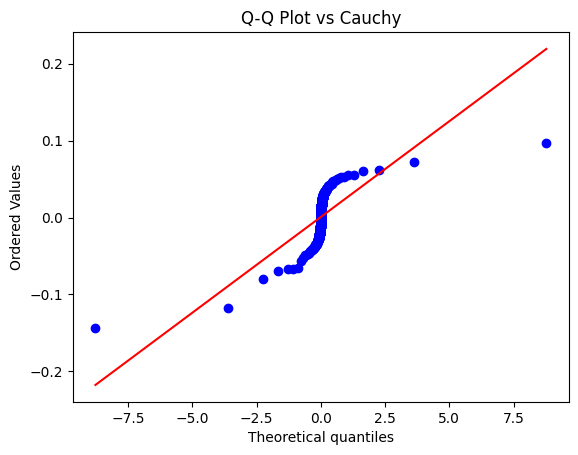

In [73]:
from scipy.stats import probplot

probplot(data, dist=cauchy(loc=loc, scale=scale), plot=plt)
plt.title('Q-Q Plot vs Cauchy')
plt.show()

In [112]:
from scipy.stats import kstest

data = residuals_train
# Estimasi parameter
loc = np.mean(data)
scale =np.var(data) #  (np.quantile(data, 0.75) - np.quantile(data, 0.25)) / 2

# Uji K-S
D, p_value = kstest(data, 'norm', args=(loc, scale))
print(f"Statistik K-S: {D}, p-value: {p_value}")

Statistik K-S: 0.4635483648460573, p-value: 0.0


In [111]:
from scipy.stats import kstest

data = residuals_test
# Estimasi parameter
loc = np.mean(data)
scale =np.var(data) #  (np.quantile(data, 0.75) - np.quantile(data, 0.25)) / 2

# Uji K-S
D, p_value = kstest(data, 'norm', args=(loc, scale))
print(f"Statistik K-S: {D}, p-value: {p_value}")

Statistik K-S: 0.47891968419452713, p-value: 0.0


In [109]:
from scipy.stats import t

# fitting parameter t distribution ke data
df, loc, scale = t.fit(data)

# baru tes
D_statistic, p_value = kstest(data, 't', args=(df, loc, scale))

print(f"KS Statistic: {D_statistic}")
print(f"P-Value: {p_value}")

KS Statistic: 0.009855130229089959
P-Value: 0.43680079998540544


## test data price error

In [62]:
mse(close_real,close_hat)

1687.8327055700352

In [63]:
rmse(close_real,close_hat)

41.083241176543446

In [64]:
mae(close_real,close_hat)

27.265054347676813

In [65]:
mape(close_real,close_hat)

0.010259279836173918

In [66]:
from sklearn.metrics import r2_score

r_squared = r2_score(close_real.reshape(2583,1),close_hat)
print("R-squared:", r_squared)


R-squared: 0.9966277106066106


In [67]:
close_real

array([1865.77, 1874.74, 1873.4 , ..., 2627.97, 2595.05, 2594.49],
      shape=(2583,))

In [68]:
close_hat

array([[1853.08905904],
       [1859.27885613],
       [1870.28829013],
       ...,
       [2640.34019459],
       [2629.35357649],
       [2593.68050302]], shape=(2583, 1))

# Plotting

In [77]:
train_date = X_train_check.iloc[6:].index
test_date = XY_data.index[(XY_data.index>='2023-7-28 15:00')
&(XY_data.index<'2024-10-01 03:00:00')]

In [82]:
combined_date = np.concatenate((train_date,test_date))
combined_return_pred = np.concatenate((prediction_train_np,prediction_np.reshape(-1)))
combined_return_real = np.concatenate((y_train,y_test))

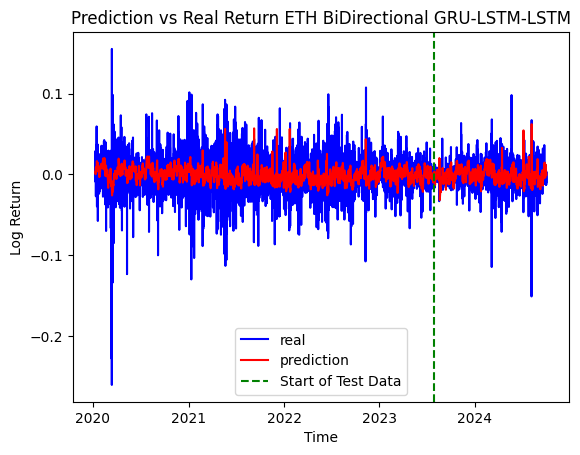

In [83]:
plt.plot(combined_date,combined_return_real, label = 'real',color='blue')

plt.plot(combined_date,combined_return_pred,label = 'prediction',color='red')
plt.axvline(test_date[0],color='green', linestyle='--', label='Start of Test Data')

plt.xlabel(
    'Time'
)
plt.ylabel('Log Return')
# plt.plot(y_test, label = 'real')
plt.title("Prediction vs Real Return ETH BiDirectional GRU-LSTM-LSTM")
plt.legend()
plt.show()

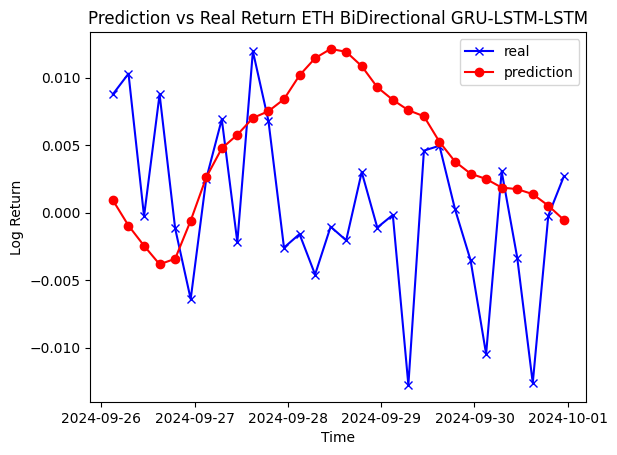

In [84]:
track_back=30
plt.plot(combined_date[-track_back:],combined_return_real[-track_back:], label = 'real',color='blue',marker='x')

plt.plot(combined_date[-track_back:],combined_return_pred[-track_back:],label = 'prediction',color='red',marker='o')
# plt.axvline(test_date[0],color='green', linestyle='--', label='Start of Test Data')

plt.xlabel(
    'Time'
)
plt.ylabel('Log Return')
# plt.plot(y_test, label = 'real')
plt.title("Prediction vs Real Return ETH BiDirectional GRU-LSTM-LSTM")
plt.legend()
plt.show()

In [89]:
combined_price_prediction = np.concatenate((predicted_price_train,close_hat.reshape(2583)))
combined_real_price = np.concatenate((close_train,close_real))

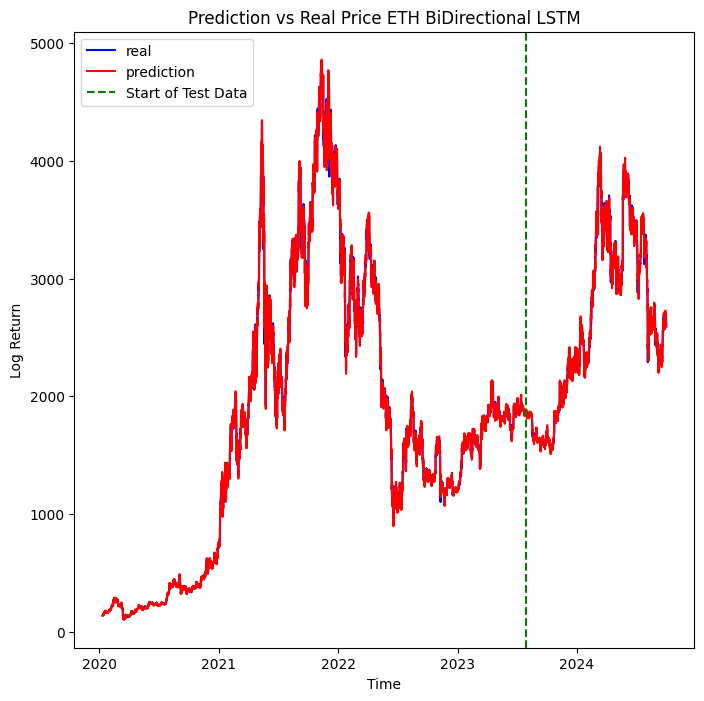

In [90]:
plt.figure(figsize=(8,8))
plt.plot(combined_date,combined_real_price, label = 'real',color='blue')

plt.plot(combined_date,combined_price_prediction,label = 'prediction',color='red')
plt.axvline(test_date[0],color='green', linestyle='--', label='Start of Test Data')

plt.xlabel(
    'Time'
)
plt.ylabel('Log Return')
# plt.plot(y_test, label = 'real')
plt.title("Prediction vs Real Price ETH BiDirectional LSTM")
plt.legend()
plt.show()

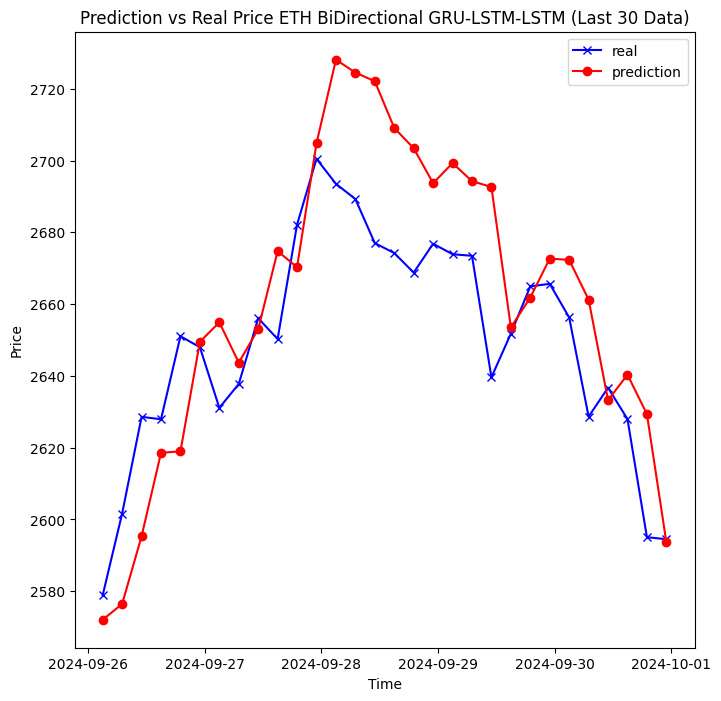

In [91]:
track_back = 30
plt.figure(figsize=(8,8))
plt.plot(combined_date[-track_back:],combined_real_price[-track_back:], label = 'real',color='blue',
        marker = 'x')

plt.plot(combined_date[-track_back:],combined_price_prediction[-track_back:],label = 'prediction',color='red',marker='o')
# plt.axvline(test_date[0],color='green', linestyle='--', label='Start of Test Data')

plt.xlabel(
    'Time'
)
plt.ylabel('Price')
# plt.plot(y_test, label = 'real')
plt.title("Prediction vs Real Price ETH BiDirectional GRU-LSTM-LSTM (Last 30 Data)")
plt.legend()
plt.savefig('last_30_price_gll.png')
plt.show()

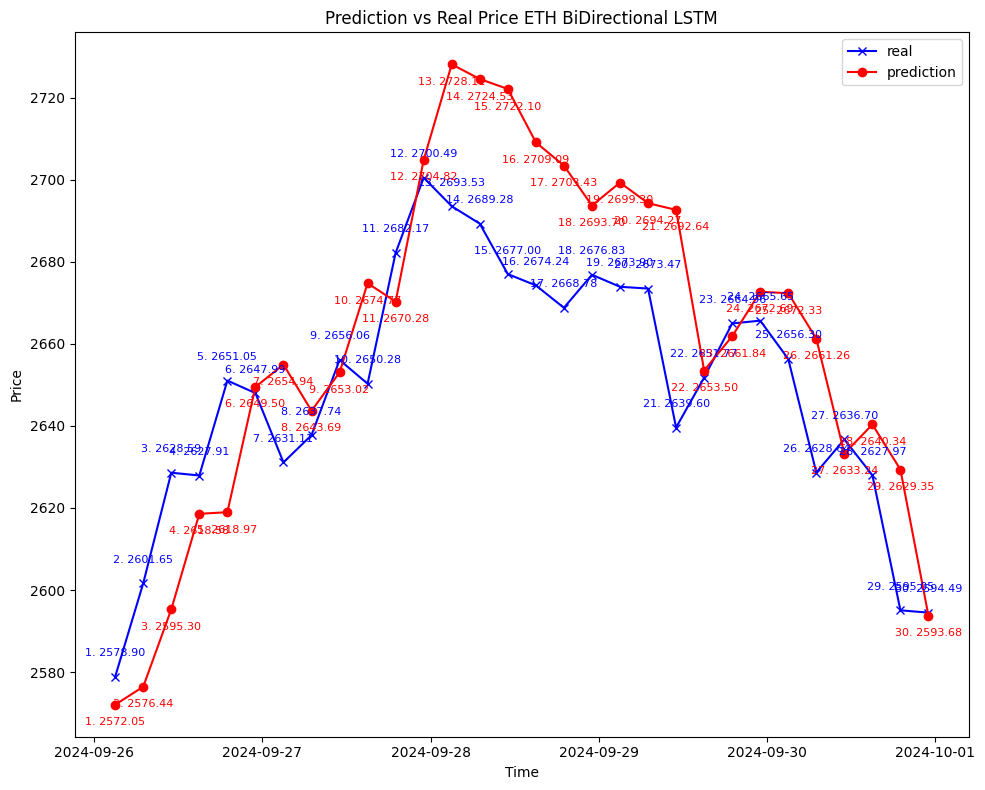

In [92]:
track_back = 30
plt.figure(figsize=(10, 8))

# Plot real prices
plt.plot(combined_date[-track_back:], combined_real_price[-track_back:], 
         label='real', color='blue', marker='x')

# Annotate real prices with index
for idx, i in enumerate(range(-track_back, 0), start=1):
    plt.text(combined_date[i], combined_real_price[i] + 5, 
             f'{idx}. {combined_real_price[i]:.2f}', 
             fontsize=8, color='blue', ha='center')

# Plot predicted prices
plt.plot(combined_date[-track_back:], combined_price_prediction[-track_back:], 
         label='prediction', color='red', marker='o')

# Annotate predicted prices with index
for idx, i in enumerate(range(-track_back, 0), start=1):
    plt.text(combined_date[i], combined_price_prediction[i] - 5, 
             f'{idx}. {combined_price_prediction[i]:.2f}', 
             fontsize=8, color='red', ha='center')

# Axes and title
plt.xlabel('Time')
plt.ylabel('Price')
plt.title("Prediction vs Real Price ETH BiDirectional LSTM")
plt.legend()
plt.tight_layout()
plt.show()


## Histogram

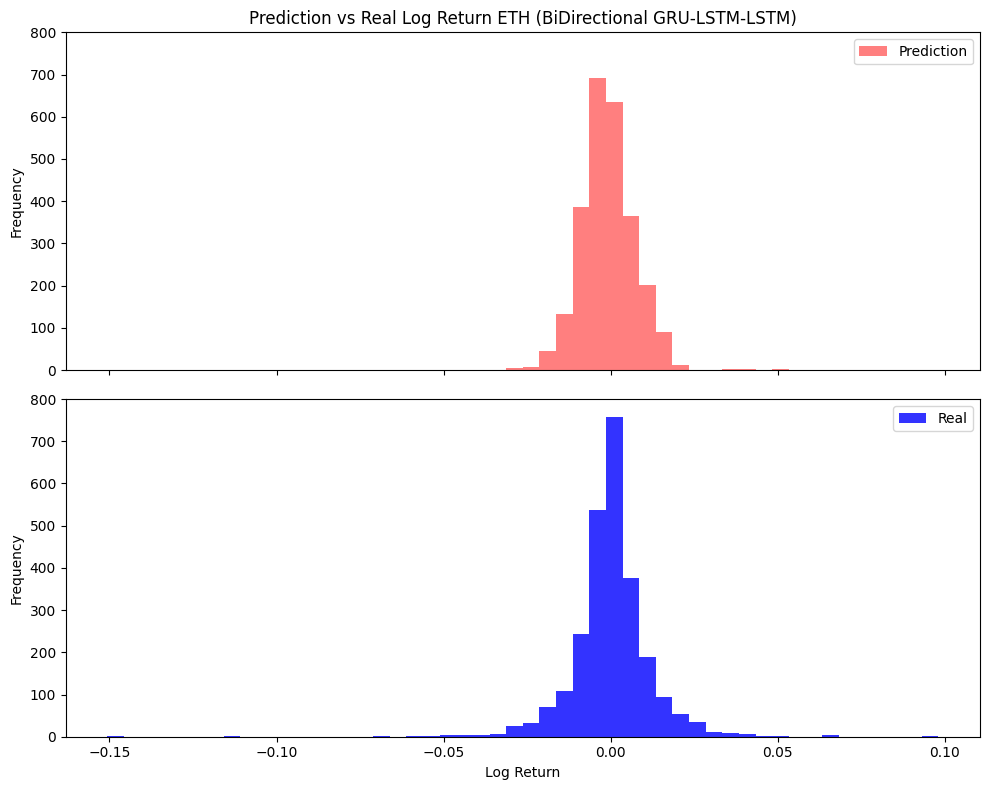

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Pastikan bin edges sama untuk kedua histogram
combined_data = np.concatenate([prediction_np.reshape(2583,), y_test])
bin_edges = np.histogram_bin_edges(combined_data, bins=50)

# Buat subplot dengan tata letak 2 baris, 1 kolom
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Histogram atas (prediction)
ax1.hist(prediction_np, bins=bin_edges, color='red', alpha=0.5, label='Prediction')
ax1.set_ylabel('Frequency')
ax1.set_ylim([0, 800])
ax1.legend()
ax1.set_title('Prediction vs Real Log Return ETH (BiDirectional GRU-LSTM-LSTM)')

# Histogram bawah (real)
ax2.hist(y_test, bins=bin_edges, color='blue', alpha=0.8, label='Real')
ax2.set_xlabel('Log Return')
ax2.set_ylabel('Frequency')
ax2.set_ylim([0, 800])
ax2.legend()

plt.tight_layout()

plt.show() 